![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Tomás Vallejo Cerda
- Estudiante n°2:

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [ ]:
# ------------ 1. Importar librerías, fijar semillas y configurar constantes ------------

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
try:
    mlflow.create_experiment("ProyectoMDS7202")
except:  # noqa: E722
    print("El experimento ya existe")
mlflow.set_experiment("ProyectoMDS7202")

# Definir constantes y fijar semillas
SEED = 20968061

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# ------------ 2. Cargar y preprocesar los datos ------------

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

2026/07/07 17:24:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 17:24:44 INFO mlflow.store.db.utils: Updating database tables


---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [2]:
# ------------ 3. Split train/val/test ------------

print("---------- Splits ----------\n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

---------- Splits ----------

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.42,39.5,39.50
Baja,36.17,36.0,36.25
Alta,17.50,17.5,17.50
Critica,6.92,7.0,6.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

1. Fijamos el split antes de entrenar porque si empezamos a probar modelos y afinar hiperparámetros mirando el mismo conjunto que después usaremos para evaluar, terminamos "espiando" el test sin darnos cuenta. El riesgo es la fuga de información, donde el modelo (o nosotros, ajustando a ojo) terminaría optimizando indirectamente sobre datos que se supone no debería ver, y el resultado final sería una estimación demasiado optimista de qué tan bien funciona en la vida real.

2. Sin un conjunto de validación aparte, terminaríamos usando el test para elegir los hiperparámetros, lo cual es el mismo problema del punto anterior pero durante la optimización en vez de durante el entrenamiento. El test dejaría de servir como medida honesta del desempeño porque ya influyó en la elección del modelo. El conjunto val nos da un lugar limpio donde probar configuraciones sin tocar el test hasta el final. La alternativa a un split fijo de validación es la validación cruzada, que resulta útil cuando hay pocos datos y no se puede dar el lujo de aislar un tercer conjunto grande.

3. Usamos un split estratificado para que cada conjunto (train/val/test) mantenga la misma proporción de clases que el dataset completo. Comentando el `stratify` y comparando vemos que con estratificación las proporciones son casi idénticas entre los tres sets (por ejemplo Baja: 36.17/36.0/36.25), pero sin ella se desordenan (Baja pasó a 38.08/33.50/33.00, casi 5 puntos de diferencia). Con solo 2000 datos, y una clase tan chica como Critica (bajo 7%), un split aleatorio puede por pura mala suerte dejar muy pocos ejemplos de esa clase en val o test, haciendo que el macro recall calculado ahí sea ruidoso y poco confiable, simplemente por cómo cayeron los dados al dividir, no por cómo realmente funciona el modelo.

4. Porque accuracy no distingue entre clases, le da el mismo peso a acertar en Media (39% de los datos) que a acertar en Critica (7%). Con este desbalance, un modelo que ignore por completo a Critica y solo aprenda a distinguir Media/Baja ya tendría un accuracy alto sin cumplir el objetivo real del negocio. El macro recall en cambio calcula el recall por separado en cada clase y las promedia con el mismo peso, obligando al modelo a rendir bien también en Critica para tener un buen puntaje general, que es justo la decisión que tomamos en la Parte 1 pensando en no descuidar los tickets más urgentes.

5. El experiment tracking es la práctica de registrar de forma sistemática cada experimento que corres: qué hiperparámetros usaste, qué métricas obtuviste, y qué artefactos generó (gráficos, modelos, reportes), todo asociado a un identificador único. Ganamos con MLflow en vez de solo imprimir métricas porque los prints viven únicamente en la memoria del kernel de Jupyter, por lo que si lo reinicias (por un error, porque se cuelga, o simplemente al otro día), se pierde todo rastro de qué habías probado y qué resultado dio. Con MLflow, esa información queda guardada en `mlflow.db`, así que puedes cerrar el notebook, abrirlo al otro día, y seguir comparando los experimentos de ayer sin tener que re-entrenar nada.

---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [3]:
import abc

import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id: str | None = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [5]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib

Regresión_Logística__Base        | Macro recall final_train=0.537  test=0.525


### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

1. Encapsular todo en `ExperimentExecutor` + `AbstractExperiment` nos da tres cosas que copiar/pegar el código de Optuna una y otra vez no nos garantiza. Primero, comparación justa: todos los experimentos pasan por exactamente el mismo protocolo (mismo split, misma métrica, mismo proceso de refit), así que si un modelo gana no es porque tuvo un tratamiento distinto por accidente. Segundo, reproducibilidad: la lógica de logging a MLflow, las semillas y el guardado de artefactos están centralizados en un solo lugar, no repetidos con pequeñas variaciones en cada celda. Tercero, menos errores: si copias/pegas 10 veces el mismo bloque de código y necesitas corregir algo (como un bug en cómo se calcula una métrica), tienes que acordarte de arreglarlo en los 10 lugares, encambio acá se arregla una vez en la clase y aplica a todos los experimentos automáticamente.

2. (a) Reentrenamos con train+val porque, una vez que ya elegimos los mejores hiperparámetros usando val, no tiene sentido seguir "reservando" esos datos, dejarlos fuera del entrenamiento final sería desperdiciar información, ya que más datos de entrenamiento generalmente ayudan a un modelo a generalizar mejor, y ya no necesitamos val para nada más (ese trabajo terminó cuando Optuna eligió la mejor configuración). 
   (b) No sería correcto conceptualmente. Si calculáramos el `macro_recall_test` de cada uno de los candidatos y eligiéramos el que mejor rindió ahí, estaríamos usando el test para tomar una decisión (cuál modelo es el mejor), y en ese momento el test deja de ser una medida honesta del desempeño futuro, dejaría de representar "datos nunca vistos" para pasar a ser otro conjunto de validación más, sólo que ahora contaminado. El riesgo de "espiar" el test de todos los candidatos es terminar eligiendo, por puro azar, al modelo que casualmente le fue mejor en esos 400 tickets específicos del test, no al que realmente generaliza mejor. Seleccionar solo por val mantiene el problema acotado porque el test se reserva completo, sin tocar, para el final, y solo se evalúa una vez sobre el modelo ya elegido, dando una estimación no sesgada de qué tan bien va a funcionar con datos nuevos.

3. Esto pasa porque durante la búsqueda de Optuna optimizamos específicamente para rendir bien en **val** dentro de 50 configuraciones distintas, Optuna eligió la que dio el mejor resultado ahí, y ese "mejor resultado" tiene algo de "suerte" incorporada, no solo buena configuración. Por ejemplo, con nuestros números, val dio 0.536, pero test dio 0.525, casi un punto porcentual menos. El test nunca fue usado para elegir nada, así que no tiene ese sesgo optimista, es una medida más honesta de qué tan bien generaliza el modelo. Que el refit use más datos (train+val) ayuda a que el modelo final sea un poco mejor, pero no alcanza a compensar el hecho de que val fue "elegido a dedo" para verse bien, mientras que test es la primera vez que el modelo se enfrenta a esos datos.

---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [11]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---

import joblib
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]

## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [12]:
class LogRegBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
            ]
        )
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Docu

Regresión_Logística__Bow         | Macro recall final_train=0.967  test=0.691


## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [13]:
class LogRegBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
            ]
        )
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Docu

Regresión_Logística__Base+Bow    | Macro recall final_train=0.994  test=0.713


## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [14]:
class LogRegEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }


exp_executor.run_experiment(
    experiment=LogRegEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/pytho

Regresión_Logística__Embeddings  | Macro recall final_train=0.936  test=0.690


## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [15]:
class LogRegFullExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegFullExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Docu

Regresión_Logística__Todo        | Macro recall final_train=0.974  test=0.716


Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

1. `Todo` funcionó mejor (test=0.716), aunque por muy poco margen sobre `Base+Bow` (0.713), una diferencia de solo 0.003, prácticamente insignificante. Lo que sí es claro es que tanto el texto como los embeddings aportan muchísimo sobre lo puramente tabular, ya que `Base` solo llega a 0.525, mientras que cualquier combinación que incluya texto o embeddings salta a 0.69-0.72.

2. El texto vía BoW fue el que aportó más señal, por lejos. El salto más grande ocurre justo al pasar de `Base` (0.525) a `Bow` (0.691)+0.166. En cambio, agregar la info tabular a eso (`Base+Bow`) solo suma +0.022 adicional, y agregar además los embeddings (`Todo`) suma apenas +0.003 más. Se concluye que la gran mayoría de la capacidad predictiva vive en el contenido del ticket, no en los metadatos.

3. Sí, `Base` sigue siendo relevante, aunque su aporte es modesto comparado con el texto, `Base+Bow` (0.713) supera a `Bow` solo (0.691) en +0.022. No es un aporte enorme, pero es consistente y no despreciable, conlcuimos que las variables tabulares (canal, categoría, antigüedad de cuenta) sí agregan algo de señal complementaria al texto.

4. No, no superó claramente. `Todo` (0.716) vs `Base+Bow` (0.713) es una diferencia de apenas 0.003, incluso dentro del margen de ruido esperable entre corridas de Optuna. Esto sugiere que los embeddings y el BoW están capturando información bastante redundante entre sí, esto es debido a que ambos derivan del mismo texto, solo que representado de dos formas distintas, así que combinarlos no le da al modelo mucha información genuinamente nueva que no tuviera ya con uno de los dos.

5. Un modelo lineal se desempeña bien en alta dimensión porque, con muchas features, es más fácil encontrar un hiperplano que separe las clases razonablemente bien, por ende, casi cualquier problema se vuelve "más separable" a medida que crece la dimensionalidad. El riesgo de eso es sobreajustar (memorizar en vez de generalizar), pero la regularización previene ese problema, permitiendo aprovechar toda la dimensionalidad sin ajustar ruido. A diferencia de un árbol, que necesita particionar el espacio corte por corte, un modelo lineal combina todas las dimensiones de una sola vez a través de sus pesos, lo cual escala mucho mejor cuando hay cientos o miles de columnas.

6. Duraciones del modelo final (refit) de cada feature-set: `Base` 4.8s, `Bow` 5.9s, `Base+Bow` 9.8s, `Embeddings` 18.1s, `Todo` 23.1 min, una diferencia de más de 100x entre el más rápido y el más lento, casi toda explicada por el costo del `permutation_importance` sobre miles de columnas. Considerando que `Base+Bow` (9.8s) rinde prácticamente igual que `Todo` (23.1 min) y que además `Todo` requiere pagar el costo de generar embeddings vía la API de `gemini-embedding-001` (tiempo de llamada + costo por token) para cada ticket nuevo en producción, `Base+Bow` es la opción más razonable, obteniendo casi el mismo desempeño, muchísimo más rápido y más barato de mantener.

7. En el gráfico de coordenadas paralelas de `Regresión_Logística__Todo`, el hiperparámetro que más se asocia con un buen `macro_recall_val` es claramente `class_weight`, donde casi todas las líneas oscuras (los mejores trials, con objective value cercano a 0.8) pasan por `balanced`, mientras que las líneas que pasan por `None` son mayoritariamente claras (peores resultados). Para `C`, los mejores trials se concentran en un rango medio, entre aproximadamente 10⁻¹ y 10¹, evitando tanto los valores muy chicos como los muy grandes. Para `l1_ratio`, las líneas oscuras tienden a agruparse hacia valores bajos, cerca de 0, sugiriendo que el modelo prefiere una regularización más cercana a Ridge (L2) que a Lasso (L1) puro. Y en `max_features`, los mejores trials se concentran en el rango medio alto, indicando que un vocabulario de BoW más grande ayuda al desempeño. En conjunto, `class_weight="balanced"` ayuda claramente, dado el desbalance de clases que ya identificamos desde la Parte 1.

8. (a) En el modelo de texto (`Base+Bow`), la columna `Texto` domina completamente la importancia (~0.43 de caída en macro recall), muy por encima de `Canal_Ticket`, `N_Caracteres_Ticket` y `Categoría_Problema`, que apenas se mueven de cero. Que permutar `Texto` derrumbe tanto la métrica significa que el modelo depende casi por completo del contenido del ticket para decidir la prioridad, por ende, si se destruye el orden/contenido de esa columna (mezclando las palabras entre tickets), el modelo pierde casi toda su capacidad predictiva. Las variables tabulares apenas mueven la aguja en comparación.

(b) En el modelo de embeddings, el top-20 lo ocupan puras dimensiones individuales (`embedding_dim_29`, `embedding_dim_386`, etc.), cada una con una importancia muy baja (entre 0.004 y 0.008, un orden de magnitud menor que el 0.43 de `Texto` en BoW) y con barras de error grandes en proporción a su tamaño. Esto confirma justamente lo que se discutió en la Sección 2 de Parte 1 sobre embeddings, donde ninguna dimensión individual es interpretable ni domina por sí sola, ya que el significado vive en la combinación de las 1024 dimensiones juntas, no en una o dos que "expliquen" la predicción. Es el reflejo esperado de una representación densa y distribuida, muy distinta a la dispersión e interpretabilidad de BoW, donde una sola columna (`Texto`, que en el fondo resume el vocabulario) concentra casi toda la señal.

---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [16]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [17]:
class ArbolBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Arbol_de_Decision"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
            ]
        )
        model = DecisionTreeClassifier(
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            ccp_alpha=hparams["ccp_alpha"],
            class_weight="balanced",
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_depth": trial.suggest_int("max_depth", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
            "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 1e-1, log=True),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=ArbolBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib

Arbol_de_Decision__Base+Bow      | Macro recall final_train=0.618  test=0.569


---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [18]:
class RandomForestBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Random_Forest"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
            ]
        )
        model = RandomForestClassifier(
            n_estimators=hparams["n_estimators"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "max_depth": trial.suggest_int("max_depth", 2, 30),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=RandomForestBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib

Random_Forest__Base+Bow          | Macro recall final_train=0.903  test=0.660


Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

1. Bagging consiste en entrenar muchos modelos base (en este caso árboles) de forma independiente, cada uno sobre una muestra distinta de los datos obtenida por remuestreo con reemplazo y además con un subconjunto aleatorio de features en cada split (en el caso de Random Forest). Al final, las predicciones de todos los árboles se promedian (o se vota, en clasificación). Esto reduce la varianza porque los errores de árboles individuales, que tienden a sobreajustar y ser inestables ante pequeños cambios en los datos, tienden a cancelarse entre sí al promediar muchos árboles distintos entrenados sobre datos ligeramente distintos, el promedio suaviza el ruido particular de cada árbol individual. Random Forest suele superar a un único árbol de decisión precisamente por esto, donde un árbol solo es propenso a memorizar particularidades del set de entrenamiento (alta varianza), mientras que el ensamble de muchos árboles, cada uno viendo una porción distinta de los datos, generaliza mejor porque ningún árbol individual domina la decisión final.

2. Sobre `Base+Bow`: Regresión Logística (0.713) > Random Forest (0.660) > Árbol de Decisión (0.569). Gana la Regresión Logística, y por un margen considerable sobre ambos modelos de árboles. Random Forest sí mejora bastante sobre el Árbol individual (+0.091), confirmando lo esperado del bagging, como se dijo antes reduce el sobreajuste de un árbol solo y generaliza mejor. Pero ninguno de los dos logra alcanzar al modelo lineal.

No es tan sorprendente considerando el feature-set `Base+Bow` mete cientos de columnas dispersas (una por cada palabra del vocabulario), y ahí un modelo lineal tiene ventaja natural, como vimos en la pregunta 5 de la sección anterior. Un árbol, en cambio, tiene que ir haciendo cortes de a una variable a la vez, con cientos de columnas de BoW, donde cada palabra individual aporta poquísima señal por sí sola, le cuesta mucho más encontrar buenos puntos de corte, y termina necesitando muchísima profundidad para aproximar lo que la regresión logística logra con una combinación lineal directa. 

---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [20]:
class LgbmBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                ),
            ]
        )
        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            verbosity=-1,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 256),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LgbmBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/

LightGBM__Bow                    | Macro recall final_train=1.000  test=0.686


/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [21]:
class LgbmEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )
        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            verbosity=-1,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 256),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
        }


exp_executor.run_experiment(
    experiment=LgbmEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvall

LightGBM__Embeddings             | Macro recall final_train=1.000  test=0.646


/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [22]:
class LgbmTodoExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )
        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            verbosity=-1,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 256),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LgbmTodoExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/tomasvallejo/

LightGBM__Todo                   | Macro recall final_train=1.000  test=0.661


/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

1. El boosting construye los árboles de forma secuencial, oséa que cada árbol nuevo se entrena específicamente para corregir los errores que dejó el conjunto de árboles anteriores, dándole más peso a los ejemplos que se están clasificando mal. Por eso ataca principalmente el sesgo, parte de un modelo simple y débil, y lo va mejorando iteración a iteración hasta reducir el error sistemático. El bagging, en cambio, entrena todos los árboles en paralelo e independientemente entre sí (cada uno sobre una muestra bootstrap distinta), y su fuerza está en promediar esos árboles para cancelar el ruido individual de cada uno (por eso ataca la varianza), no el sesgo.

2. No parece ser la mejor idea, aunque la diferencia es más modesta de lo que uno esperaría, `LightGBM__Embeddings` (test=0.646) rinde algo peor que `Regresión_Logística__Embeddings` (test=0.690), una caída de 0.044 (~6% relativo). La razón de fondo es cómo un árbol construye sus cortes, donde en cada split elige, de forma voraz, una sola dimensión y un umbral que separa las clases en ese momento, sin considerar cómo se combina con el resto. Un modelo lineal, en cambio, combina las 1024 dimensiones simultáneamente a través de sus pesos. Esto le pega especialmente fuerte a los embeddings por dos motivos: primero, ninguna dimensión individual tiene significado propio, la información vive en la combinación. Segundo, al ser 1024 dimensiones parcialmente correlacionadas entre sí, la ganancia de información de cualquier split queda diluida entre muchas dimensiones parecidas, y ninguna destaca lo suficiente como para que el árbol se ancle en ella con confianza. Que la brecha no sea enorme se explica porque LightGBM compensa parcialmente con boosting, al encadenar cientos de árboles, cada uno puede ir aprovechando una dimensión distinta y sumando pequeños aportes que, acumulados, se acercan (sin igualar del todo) a lo que el modelo lineal logra de una sola vez.

3. Para LightGBM, el mejor feature-set fue `Bow` (test=0.686), seguido de `Todo` (0.661) y `Embeddings` (0.646). BoW le gana a Embeddings también con este modelo, igual como ya había pasado con la Regresión Logística. Comparado con la mejor Regresión Logística (`Todo`, test=0.716, aunque `Base+Bow` con 0.713 es prácticamente igual), el mejor LightGBM (0.686) queda por debajo en cualquier combinación, por ende la Regresión Logística sigue siendo el modelo ganador hasta ahora.

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [27]:
from sklearn.neural_network import MLPClassifier


class MlpEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "MLP"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )
        if hparams["n_layers"] == 1:
            hidden_layer_sizes = (hparams["n_units_1"],)
        else:
            hidden_layer_sizes = (hparams["n_units_1"], hparams["n_units_2"])

        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=hparams["alpha"],
            max_iter=300,
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        n_layers = trial.suggest_int("n_layers", 1, 2)
        hparams = {
            "n_layers": n_layers,
            "n_units_1": trial.suggest_categorical("n_units_1", [32, 64, 128, 256]),
            "alpha": trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
        }
        if n_layers == 2:
            hparams["n_units_2"] = trial.suggest_categorical("n_units_2", [16, 32, 64, 128])
        return hparams


exp_executor.run_experiment(
    experiment=MlpEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/var/folders/lg/cd1bshgs3t1dk5qzztv7ngm40000gn/T/ipykernel_51265/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:

MLP__Embeddings                  | Macro recall final_train=0.962  test=0.731


Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

1. Sí, se adapta muy bien, de hecho es el mejor resultado sobre embeddings de los tres modelos probados: MLP (test=0.731) > Regresión_Logística (0.690) > LightGBM (0.646). Tiene sentido, ya que al igual que el modelo lineal, la red opera sobre el vector completo de 1024 dimensiones a la vez (no dimensión por dimensión como un árbol), pero además puede aprender combinaciones no lineales entre esas dimensiones gracias a las capas ocultas y sus funciones de activación. Esa capacidad extra de modelar interacciones complejas entre dimensiones parece aprovechar mejor la estructura geométrica de los embeddings.

2. Sin `class_weight`, la red trata cada ejemplo de entrenamiento con el mismo peso durante la optimización, sin importar a qué clase pertenece. Con nuestro desbalance, la función de pérdida terminaría dominada por las clases mayoritarias, ya que hay muchos más ejemplos de ellas empujando el gradiente en esa dirección, por ende el modelo tendría poco incentivo a aprender bien los patrones de Critica, arriesgando un macro recall más bajo específicamente en esa clase, aunque el desempeño promedio (o el accuracy) se vea razonable. Alternativas para manejar esto en una red: 
   - **Sobremuestreo/submuestreo** de los datos antes de entrenar (por ejemplo SMOTE, o simplemente duplicar ejemplos de las clases minoritarias) para balancear las proporciones que ve el modelo.
   - **Pesos por muestra manuales**: aunque `MLPClassifier` no tiene `class_weight`, sí acepta pasar pesos calculados a mano y aplicarlos a la función de pérdida de otras formas.
   - **Ajustar el umbral de decisión** por clase después de entrenar, en vez de tocar el entrenamiento mismo.

3. La principal desventaja es la cantidad de hiperparámetros e hipótesis de arquitectura que hay que explorar, mientras la Regresión Logística solo necesita buscar `C` y `l1_ratio`, la red agrega decisiones sobre cuántas capas ocultas usar y cuántas neuronas por capa, que no es un solo número sino una combinatoria de arquitecturas posibles, además de `alpha`. Eso hace que el espacio de búsqueda sea mucho más grande y más caro de explorar con Optuna para encontrar una buena configuración. En cuanto a costo computacional puro, entrenar una red implica optimizar muchos más parámetros internos (pesos de cada capa) mediante backpropagation iterativo, comparado con la Regresión Logística que resuelve un problema convexo mucho más simple y directo, por eso aun con las mismas 1024 columnas de entrada, la red tiende a tardar más que el modelo lineal.

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [31]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

,study_name,macro_recall_val,macro_recall_test,recall_test_Critica
0,Regresión_Logística__Todo,0.812005,0.715602,0.444444
1,Regresión_Logística__Base+Bow,0.803479,0.712676,0.444444
2,MLP__Embeddings,0.787462,0.730574,0.444444
3,Regresión_Logística__Embeddings,0.783667,0.690059,0.222222
4,MLP__Embeddings,0.777005,0.730574,0.444444
5,Regresión_Logística__Bow,0.764893,0.690736,0.370370
6,LightGBM__Bow,0.764401,0.685901,0.296296
7,LightGBM__Todo,0.743369,0.661050,0.185185
8,Random_Forest__Base+Bow,0.729586,0.660461,0.444444
9,LightGBM__Embeddings,0.718826,0.645724,0.222222


Mejor modelo (por macro recall en val): Regresión_Logística__Todo
  macro_recall_val   : 0.812
  macro_recall_test  : 0.716
  recall_test_Critica: 0.444


Macro recall (test): 0.716
              precision    recall  f1-score   support

        Alta       0.61      0.73      0.67        70
        Baja       0.87      0.92      0.89       145
     Critica       0.63      0.44      0.52        27
       Media       0.84      0.77      0.81       158

    accuracy                           0.80       400
   macro avg       0.74      0.72      0.72       400
weighted avg       0.80      0.80      0.79       400



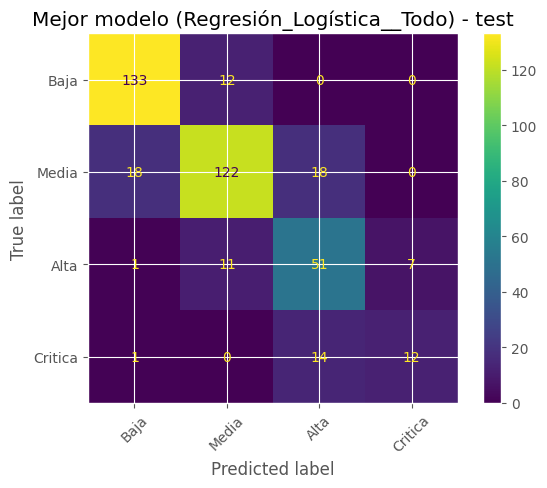

In [29]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [30]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

2026/07/07 23:51:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/07 23:51:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modelo exportado a modelo_final.pkl


Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

1. El test se deja para el final, y la selección se hace por val, para no contaminar la decisión de "cuál modelo es mejor" con información del conjunto que se supone debe medir el desempeño real y honesto en datos nunca vistos. Si eligiéramos el modelo mirando quién tiene mejor test entre los 10 candidatos, estaríamos usando el test para tomar una decisión, por lo que dejaría de ser una medida no sesgada, porque ya habría influido en qué modelo terminamos escogiendo. Por ejemplo en nuestro caso si hubiéramos mirado test en vez de val, habríamos elegido `MLP__Embeddings` (test=0.731) en vez de `Regresión_Logística__Todo` (val=0.812, el más alto), simplemente porque en esos 400 tickets específicos del test le fue mejor al MLP, pero eso podría ser parcialmente suerte del split, no necesariamente que el MLP generalice mejor en general. Guardar el test val intacto hasta el final, y usarlo solo para confirmar qué tan bien le va al modelo ya elegido (no para elegir entre candidatos), es lo que mantiene esa medida final honesta.

2. Además del macro recall, consideraría: latencia de inferencia (cuánto tarda en responder por ticket, relevante si se prioriza en tiempo real), costo de mantenerlo corriendo, facilidad de explicar sus decisiones al equipo de soporte, y qué tan dependiente es de servicios externos.

Justo el modelo elegido usa embeddings, y eso trae una implicación concreta en producción, en que para clasificar un ticket nuevo hay que llamar en tiempo real a la API de `gemini-embedding-001` antes de poder predecir, lo que agrega latencia de red, costo por token en cada llamada, y una dependencia externa, por ejemplo si la API de Google tiene una caída o rate-limiting, el sistema de priorización completo deja de funcionar. Además, si el proveedor actualiza el modelo de embeddings, el espacio vectorial podría cambiar y el modelo entrenado quedaría desactualizado sin que nadie lo note de inmediato. POr lo tanto, vale la pena recordar que `Base+Bow` rinde casi idéntico a `Todo` (solo 0.003 de diferencia) sin ninguna de estas dependencias, siendo un argumento fuerte a favor de la opción más simple en producción.

3. Mirando la fila de `Critica` en el classification_report: recall=0.44, precision=0.63, f1=0.52, sobre un soporte de solo 27 tickets reales en el conjunto de test. Viendo la matriz de confusión, de esos 27 tickets críticos reales: 12 se clasificaron correctamente como Critica, 14 se confundieron con Alta, y 1 se confundió con Baja.

Esto es parcialmente aceptable para el objetivo de negocio, pero no ideal. Lo positivo es que la gran mayoría de los errores (14 de 15) caen en Alta, la clase adyacente, por lo que un ticket crítico mal clasificado como Alta igual va a recibir atención prioritaria, aunque no la máxima, así que el daño real es acotado. Lo preocupante es que hay 1 ticket verdaderamente crítico que el modelo clasificó como Baja, siendo el peor error posible, un caso de fraude o urgencia real que terminaría con la prioridad más baja posible, sin ninguna señal de alarma. Con un recall de apenas 0.44, más de la mitad de los tickets críticos reales no quedan etiquetados como tal. Para el objetivo de negocio (no descuidar lo urgente), esto sugiere que el modelo por sí solo no es suficiente como única línea de defensa.

4. Revisando el run de refit del modelo elegido, esto es lo que MLflow ya deja registrado:

   - El pipeline completo serializado (preprocessing + modelo), junto con su `signature`, un `input_example`, y el archivo de entorno (conda.yaml). Con eso cualquiera puede cargar el modelo con `mlflow.sklearn.load_model()` sin tener que reconstruir el `ColumnTransformer` a mano.
   - Los hiperparámetros ganadores (`C`, `l1_ratio`, `class_weight`, `max_features`).
   - El tamaño de cada split (`n_train`, `n_val`, `n_test`, `n_train_final`), útil para verificar que alguien reentrenando llegue a números comparables.
   - Las métricas completas de test: precision/recall/f1 por cada clase, no solo el macro recall.
   - El commit exacto de git, la rama y el usuario que corrió el experimento, lo que permite volver al código exacto que generó este modelo.

   Agregaría, porque no está: la semilla (`SEED`) como parámetro explícito, ya que sin ella, alguien que quiera reproducir el mismo split o la misma inicialización del modelo no tiene forma de saberla. Y la versión o fecha del modelo `gemini-embedding-001` usado para generar los embeddings, ya que estos se calculan fuera de este notebook y no queda ningún rastro de qué versión se usó.

5. No completamente. La ganancia de `Regresión_Logística__Todo` sobre `Regresión_Logística__Base+Bow` es estadísticamente insignificante, y ese pequeño extra viene con el costo real de depender de una API externa de embeddings en cada inferencia (latencia, costo, punto único de falla), como se discutió anteriormente. 

Por ende, a producción llevaría `Regresión_Logística__Base+Bow`, prácticamente el mismo desempeño, sin dependencia de servicios externos, con inferencia mucho más rápida y barata (9.8s de refit vs los 23 minutos que tomó `Todo`, reflejo del costo computacional general), y más simple de mantener y depurar si algo falla. La complejidad extra de sumar embeddings no se traduce en una mejora de negocio real, solo en más superficie de fallo.